In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import pandas as pd

path = '/content/drive/MyDrive/Praktikum/praktikum07/data/apples_and_oranges.csv'
df = pd.read_csv(path)

df.head()


,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


In [47]:
df.describe()

,Weight,Size
count,40.000000,40.000000
mean,70.200000,4.922750
std,3.039906,0.590063
min,65.000000,4.010000
25%,68.000000,4.360000
50%,70.000000,4.930000
75%,73.000000,5.472500
max,75.000000,5.850000


In [48]:
df["Class"].unique()

array(['orange', 'apple'], dtype=object)

In [49]:
df["Class"].value_counts()

,count
Class,
orange,20
apple,20


In [50]:
X = df[['Size','Weight']]

y = df[['Class']]

In [51]:
X.head()

,Size,Weight
0,4.39,69
1,4.21,69
2,4.09,65
3,5.85,72
4,4.70,67


In [52]:
y.head()

,Class
0,orange
1,orange
2,orange
3,apple
4,orange


In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear')

In [69]:
y_pred = model.predict(X_test)
print(f"Akurasi: {accuracy_score(y_test, y_pred) *100:0.2f}%")
print(f"\nlaporan klasifikasi:\n{classification_report(y_test, y_pred)}")

Akurasi: 84.38%

laporan klasifikasi:
              precision    recall  f1-score   support

       apple       1.00      0.71      0.83        17
      orange       0.75      1.00      0.86        15

    accuracy                           0.84        32
   macro avg       0.88      0.85      0.84        32
weighted avg       0.88      0.84      0.84        32




Confusion Matrix:
 [[12  5]
 [ 0 15]]


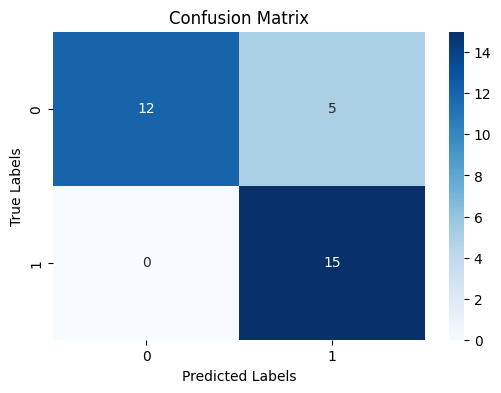

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Jika kamu tahu nama kelas (opsional, agar lebih informatif)
# misalnya: class_names = ['Negatif', 'Positif']
# maka tambahkan ke heatmap di bagian "xticklabels" dan "yticklabels"

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


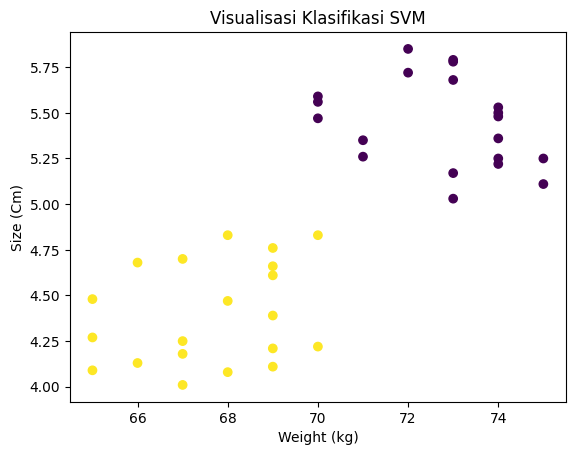

In [56]:
import matplotlib.pyplot as plt

plt.scatter(df['Weight'], df['Size'], c=df['Class'].astype('category').cat.codes)
plt.xlabel('Weight (kg)')
plt.ylabel('Size (Cm)')
plt.title('Visualisasi Klasifikasi SVM')
plt.show()
